In [3]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mahmudurrahmansupto/baangla-btrc/combined_dataset_v3-002.jsonl


In [4]:
print("hello")

hello


In [5]:
print ("name is mahmudur rahman supto")

name is mahmudur rahman supto


In [6]:
print ("hello world")

hello world


In [7]:
import glob, json, re, collections
import pandas as pd
import numpy as np

PATH = glob.glob('/kaggle/input/**/combined_dataset_v3-002.jsonl', recursive=True)[0]
print(PATH)

rows, bad = [], 0
with open(PATH, encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except json.JSONDecodeError:
            bad += 1
print(f"records: {len(rows):,} | malformed lines: {bad}")
df = pd.json_normalize(rows)
print(df.shape)
df.head()

/kaggle/input/datasets/mahmudurrahmansupto/baangla-btrc/combined_dataset_v3-002.jsonl
records: 486,969 | malformed lines: 0
(486969, 4)


,text,title,source_dataset,original_source
0,"বাংলা ভাষা (বাঙলা, বাঙ্গলা তথা বাঙ্গালা নামেও ...",বাংলা ভাষা,data-1,wikipedia
1,নির্বাচিত নিবন্ধ\n \n \n \n \n \n \n \n \n \n ...,প্রধান পাতা,data-1,wikipedia
2,বাংলাদেশ () দক্ষিণ এশিয়ার একটি স্বাধীন সার্বভ...,বাংলাদেশ,data-1,wikipedia
3,"দুর্গা (; অর্থাৎ ""যিনি দুর্গতি বা সংকট থেকে রক...",দুর্গা,data-1,wikipedia
4,আনন্দমঠ ঊনবিংশ শতাব্দীর ঔপন্যাসিক বঙ্কিমচন্দ্র...,আনন্দমঠ,data-1,wikipedia


In [8]:
# Schema: dtypes, nulls, example values
info = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'nulls': df.isna().sum(),
    'null_%': (df.isna().mean()*100).round(2),
    'unique': df.apply(lambda s: s.astype(str).nunique()),
    'example': df.apply(lambda s: str(s.dropna().iloc[0])[:80] if s.notna().any() else None),
})
info

,dtype,nulls,null_%,unique,example
text,object,0,0.00,486969,"বাংলা ভাষা (বাঙলা, বাঙ্গলা তথা বাঙ্গালা নামেও ..."
title,object,74,0.02,465762,বাংলা ভাষা
source_dataset,object,0,0.00,3,data-1
original_source,object,0,0.00,6,wikipedia


In [9]:
# Identify text columns and compute length stats (chars / words)
text_cols = [c for c in df.columns if df[c].map(lambda x: isinstance(x, str)).mean() > 0.9
             and df[c].dropna().astype(str).str.len().mean() > 20]
print("text columns:", text_cols)

stats = {}
for c in text_cols:
    s = df[c].fillna('').astype(str)
    stats[c] = {
        'empty': int((s.str.strip()=='').sum()),
        'chars_mean': s.str.len().mean(), 'chars_median': s.str.len().median(),
        'chars_p95': s.str.len().quantile(.95), 'chars_max': s.str.len().max(),
        'words_mean': s.str.split().str.len().mean(),
        'words_p95': s.str.split().str.len().quantile(.95),
    }
pd.DataFrame(stats).T.round(1)

text columns: ['text', 'title']


,empty,chars_mean,chars_median,chars_p95,chars_max,words_mean,words_p95
text,0.0,2711.5,1799.0,6963.0,777439.0,389.8,1014.6
title,74.0,27.7,26.0,52.0,116.0,4.1,8.0


In [10]:
# Duplicates and low-cardinality (label/category) columns
print("exact duplicate rows:", df.astype(str).duplicated().sum())
for c in text_cols:
    print(f"duplicate '{c}':", df[c].duplicated().sum())

for c in df.columns:
    if c in text_cols: continue
    n = df[c].astype(str).nunique()
    if n <= 30:
        print(f"\n== {c} ({n} values) ==")
        print(df[c].astype(str).value_counts().head(30))

exact duplicate rows: 0
duplicate 'text': 0
duplicate 'title': 21207

== source_dataset (3 values) ==
source_dataset
data-3    298064
data-1    188732
data-2       173
Name: count, dtype: int64

== original_source (6 values) ==
original_source
              298064
wikipedia     184506
wikibooks       4225
journal           99
textbook          74
wikisource         1
Name: count, dtype: int64


In [11]:
# Script composition: Bangla vs Latin vs digits vs other, per text column
def script_ratio(t):
    t = str(t); n = max(len(t), 1)
    bn = len(re.findall(r'[\u0980-\u09FF]', t))
    en = len(re.findall(r'[A-Za-z]', t))
    dg = len(re.findall(r'[0-9\u09E6-\u09EF]', t))
    return bn/n, en/n, dg/n

for c in text_cols:
    r = np.array([script_ratio(t) for t in df[c].fillna('').head(50000)])
    print(f"{c}: bangla={r[:,0].mean():.2%} latin={r[:,1].mean():.2%} digits={r[:,2].mean():.2%}")
    print("  rows with <50% Bangla chars:", int((r[:,0] < .5).sum()))

text: bangla=78.15% latin=3.47% digits=2.71%
  rows with <50% Bangla chars: 1327
title: bangla=92.01% latin=0.01% digits=5.04%
  rows with <50% Bangla chars: 7


In [12]:
# Data quality: URLs, HTML, control/odd chars, leading/trailing whitespace
checks = {
    'url': r'https?://|www\.',
    'html_tag': r'<[^>]+>',
    'zero_width': r'[\u200b\u200c\u200d\ufeff]',
    'repeated_chars(5+)': r'(.)\1{4,}',
    'multi_space': r'\s{3,}',
}
q = {}
for c in text_cols:
    s = df[c].fillna('').astype(str)
    q[c] = {k: int(s.str.contains(v, regex=True).sum()) for k, v in checks.items()}
    q[c]['edge_whitespace'] = int((s != s.str.strip()).sum())
pd.DataFrame(q).T

/tmp/ipykernel_58/998103092.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  q[c] = {k: int(s.str.contains(v, regex=True).sum()) for k, v in checks.items()}
/tmp/ipykernel_58/998103092.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  q[c] = {k: int(s.str.contains(v, regex=True).sum()) for k, v in checks.items()}


,url,html_tag,zero_width,repeated_chars(5+),multi_space,edge_whitespace
text,7017,3546,48364,2601,173531,0
title,0,0,3140,4,11,0


In [13]:
# Character & token frequency (Bangla vocabulary overview)
main = max(text_cols, key=lambda c: df[c].astype(str).str.len().sum())
print("main text column:", main)
sample = df[main].dropna().astype(str).sample(min(50000, len(df)), random_state=0)
words = collections.Counter(w for t in sample for w in re.findall(r'[\u0980-\u09FF]+', t))
print("vocab size (sample):", len(words), "| total tokens:", sum(words.values()))
pd.DataFrame(words.most_common(30), columns=['word','count'])

main text column: text
vocab size (sample): 612872 | total tokens: 19904153


,word,count
0,ও,218083
1,এবং,204988
2,করে,170337
3,হয়,146005
4,থেকে,123520
5,করা,120430
6,বিষয়শ্রেণী,117210
7,একটি,113601
8,এই,111059
9,এ,109550


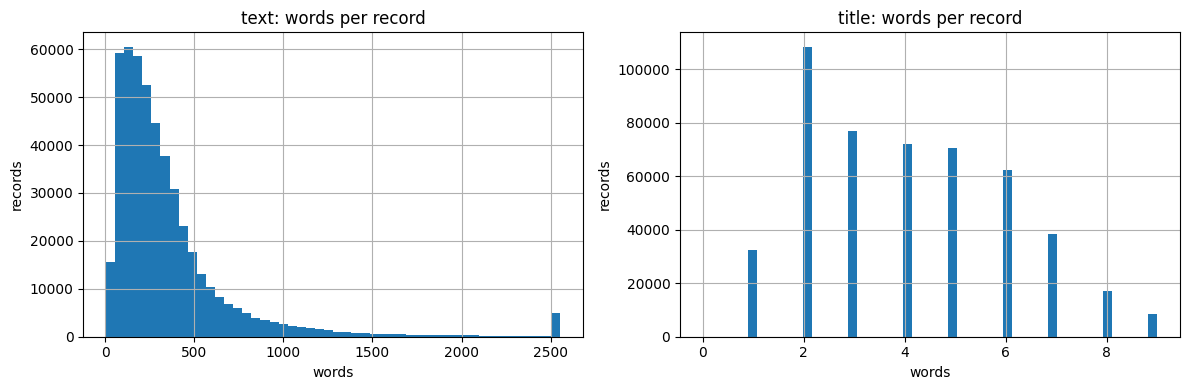

In [14]:
# Distribution plots
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(text_cols), figsize=(6*len(text_cols), 4), squeeze=False)
for ax, c in zip(axes[0], text_cols):
    df[c].fillna('').astype(str).str.split().str.len().clip(upper=df[c].fillna('').astype(str).str.split().str.len().quantile(.99)).hist(bins=50, ax=ax)
    ax.set_title(f'{c}: words per record'); ax.set_xlabel('words'); ax.set_ylabel('records')
plt.tight_layout(); plt.show()

In [15]:
# Random samples for manual inspection
for _, r in df.sample(5, random_state=1).iterrows():
    print(json.dumps(r.to_dict(), ensure_ascii=False, default=str)[:600]); print('-'*60)

{"text": "আমি এই পর্বের শুরু গণ্য করি কাম্মু তেন্‌নো-র মৃত্যুর (৮০৬ খ্রি.) পর থেকে ফুজিওয়ারা নো তোকিহিরা-র মৃত্যুর (৯০৯ খ্রি.) সময় পর্যন্ত। যদিও এ সময়সীমার সমাপ্তির জন্য একাধিক সম্ভাব্য পয়েন্ট রয়েছে, এই সময়সীমা শেষ হয়ে যাওয়াকে এক অর্থে টেন্‌চি তেন্‌নো এবং তেম্‌মু তেন্‌নো কর্তৃক আসুকা যুগে প্রবর্তিত শাসনব্যবস্থা ও সামাজিক সংগঠনের মডেল পুনরুজ্জীবিত করার শেষ প্রচেষ্টার সমাপ্তি হিসেবে চিহ্নিত করা যায়। প্রারম্ভিক হেইয়ান যুগ স্পষ্টভাবে নারা যুগের ধারাবাহিকতা ছিল, কারণ এই সময় জুড়েই সরকার ৬৯৪ ও ৭০১ সালের আইন-সংহিতায় প্রবর্তিত \"রিতসু-রিও\" ব্যবস্থা কার্যকর করার জন্য প্রতিশ্রুতিবদ্ধ ছিল। অ
------------------------------------------------------------
{"text": "বরিশাল বিভাগের ছয় জেলার সরকারি হাসপাতালগুলোতে চলছে চিকিৎসক-সংকট। এতে ব্যাহত হচ্ছে চিকিৎসাসেবা। সার্জারি ও অবেদনবিদসহ কনিষ্ঠ বিশেষজ্ঞ চিকিৎসক-সংকটের কারণে অনেক হাসপাতালে অস্ত্রোপচারও বন্ধ রয়েছে। এই বিভাগের প্রায় ১ কোটি মানুষের মধ্যে প্রতি ১৮ হাজারের জন্য আছেন মাত্র একজন চিকিৎসক।বিভাগীয় স্বাস্থ্য কর্মকর্তাদের দেওয়া তথ্য অনু

In [ ]:
# ===== CLEANING =====
import unicodedata

URL_RE      = re.compile(r'https?://\S+|www\.\S+')
HTML_RE     = re.compile(r'<[^>]+>')
ZW_RE       = re.compile(r'[﻿​⁠]')          # keep ZWJ/ZWNJ: used in Bangla conjuncts
EMPTY_PAREN = re.compile(r'\(\s*[;,:]?\s*\)')                # "()", "(;)" left by removed Wikipedia templates
LEAD_SEMI   = re.compile(r'\(\s*[;,]\s*')                    # "(; জন্ম" -> "(জন্ম"
REPEAT_RE   = re.compile(r'(.)\1{4,}')                       # aaaaa, ্্্্্্
CATEGORY_RE = re.compile(r'^\s*বিষয়শ্রেণী\s*:?.*$', re.M)    # wikipedia category lines
BN_RE       = re.compile(r'[ঀ-৿]')

def clean_text(t: str) -> str:
    t = unicodedata.normalize('NFC', t)
    t = ZW_RE.sub('', t)
    t = HTML_RE.sub(' ', t)
    t = URL_RE.sub(' ', t)
    t = CATEGORY_RE.sub('', t)
    t = EMPTY_PAREN.sub('', t)
    t = LEAD_SEMI.sub('(', t)
    t = REPEAT_RE.sub(r'\1\1', t)
    t = re.sub(r'[ \t ]+', ' ', t)
    t = '\n'.join(line.strip() for line in t.split('\n'))
    t = re.sub(r'\n{3,}', '\n\n', t)
    return t.strip()

def bn_ratio(t): return len(BN_RE.findall(t)) / max(len(t), 1)

df['text_clean'] = df['text'].map(clean_text)
print("avg chars before/after:", df['text'].str.len().mean().round(0), df['text_clean'].str.len().mean().round(0))

In [ ]:
# ===== FILTERING =====
MIN_CHARS, MIN_BN_RATIO = 200, 0.6

before = len(df)
df['len_clean'] = df['text_clean'].str.len()
df['bn_ratio']  = df['text_clean'].map(bn_ratio)

mask = (df['len_clean'] >= MIN_CHARS) & (df['bn_ratio'] >= MIN_BN_RATIO)
mask &= df['title'].fillna('') != 'প্রধান পাতা'              # wikipedia main page
print(f"too short: {(df.len_clean < MIN_CHARS).sum()} | low Bangla: {(df.bn_ratio < MIN_BN_RATIO).sum()}")

df = df[mask].copy()
# near-duplicate removal: same first 300 chars
key = df['text_clean'].str[:300]
df = df[~key.duplicated()].copy()
df['original_source'] = df['original_source'].replace('', 'news')   # data-3 has no label
print(f"kept {len(df):,} / {before:,}")
print(df.groupby(['source_dataset','original_source']).size())

In [ ]:
# ===== TOKENIZER EFFICIENCY (Llama tokenizer on Bangla) =====
from transformers import AutoTokenizer

MODEL_NAME = "unsloth/Meta-Llama-3.1-8B"   # ungated mirror; Llama 3.2 has only 1B/3B text models (set to 3.2-3B if preferred)
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

samp = df['text_clean'].sample(2000, random_state=0)
n_tok   = sum(len(tok(t, add_special_tokens=False)['input_ids']) for t in samp)
n_words = samp.str.split().str.len().sum()
n_chars = samp.str.len().sum()
print(f"tokens/word: {n_tok/n_words:.2f} | chars/token: {n_chars/n_tok:.2f}")
est_total = n_tok / n_chars * df['len_clean'].sum()
print(f"estimated total tokens in cleaned corpus: {est_total/1e6:.0f}M")

In [ ]:
# ===== BUILD TRAINING SUBSET + CHUNK + SPLIT =====
import random, os
MAX_TOKENS     = 1024             # context per training example (raise if GPU allows)
TOKEN_BUDGET   = 30_000_000       # ~what fits a Kaggle session budget; tune after seeing speed
CHARS_PER_TOK  = n_chars / n_tok  # measured above
MAX_CHARS      = int(MAX_TOKENS * CHARS_PER_TOK * 0.95)

def chunk(text, max_chars=MAX_CHARS):
    """Split on paragraph boundaries into <= max_chars pieces; hard-split oversize paragraphs."""
    out, cur = [], ''
    for para in text.split('\n\n'):
        while len(para) > max_chars:
            if cur: out.append(cur); cur = ''
            out.append(para[:max_chars]); para = para[max_chars:]
        if len(cur) + len(para) + 2 > max_chars and cur:
            out.append(cur); cur = para
        else:
            cur = f"{cur}\n\n{para}" if cur else para
    if cur: out.append(cur)
    return [c for c in out if len(c) >= MIN_CHARS]

# balance sources so news/wiki/books all appear: cap wikipedia & news, keep all small sources
random.seed(42)
records = []
for _, r in df.sample(frac=1, random_state=42).iterrows():
    for c in chunk(r['text_clean']):
        records.append({'text': c, 'source': r['original_source']})

random.shuffle(records)
keep, used = [], 0
for rec in records:
    keep.append(rec); used += len(rec['text']) / CHARS_PER_TOK
    if used >= TOKEN_BUDGET: break
print(f"chunks total: {len(records):,} | selected: {len(keep):,} (~{used/1e6:.1f}M tokens)")
print(pd.Series([k['source'] for k in keep]).value_counts())

n_val = max(1000, int(0.01 * len(keep)))
val, train = keep[:n_val], keep[n_val:]
os.makedirs('/kaggle/working', exist_ok=True)
for name, data in [('train', train), ('val', val)]:
    with open(f'/kaggle/working/{name}.jsonl', 'w', encoding='utf-8') as f:
        for d in data: f.write(json.dumps(d, ensure_ascii=False) + '\n')
print("train:", len(train), "val:", len(val))